<a href="https://colab.research.google.com/github/sungfeliks/Sentiment-Analysis-of-Free-Meal-Program-in-Indonesia/blob/main/sentimentAnalysis_Free-Meal-Program-Indonesia_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Upload Dataset Langsung**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Data_Sentimen_MBG.csv to Data_Sentimen_MBG.csv


# **Persiapan Library**

In [2]:
# Install semua library yang kira-kira dibutuhkan, kalau ada yang kurang, bisa diinstall di cell selanjutnya kalau terlupakan
!pip install -q transformers datasets scikit-learn matplotlib seaborn tqdm pandas numpy tensorboard torch nltk wordcloud ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.6 MB/s eta 0:00:00


In [3]:
# Import semua librarynya
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from collections import Counter
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re, os, time
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, pipeline
)
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from datasets import Dataset as HfDataset

# Cek GPU (Pastikan CUDA-nya available, biar lebih cepat proses trainingnya)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Buat folder untuk menyimpan model & hasil (penting untuk pengumpulan nanti)
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("logs/tensorboard", exist_ok=True)

Device: cuda


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **Baca Dataset**

In [4]:
# Baca file csv
df = pd.read_csv('Data_Sentimen_MBG.csv') #Disclaimer: Saya tidak memiliki maksud untuk mennyindir pihak tertentu, dataset murni untuk pengerjaan proyek saja.
print("Shape awal:", df.shape)
df.head()

Shape awal: (6419, 5)


,author,published_at,like_count,text,public
0,@Ipank049,2026-03-15T19:00:49Z,0,Penguasa dan Pelaksana Program MBG menjadi Pen...,True
1,@Tmsaja873,2026-03-15T11:15:42Z,0,anaknya makan 1x bapaknya penganguran..,True
2,@fakhrieofisial4819,2026-03-15T07:36:34Z,0,"Rusak lah negara kalau Nepotisme, korupsi sema...",True
3,@sudaryadidar1358,2026-03-14T08:23:35Z,0,Programpresiden jokowi. Berobat gratid banyak ...,True
4,@KokGiniAmat,2026-03-14T06:33:38Z,0,Maling Berkedok Gizi,True


In [5]:
print(df["text"].sample(3).values)

['Ada udang di balik proyek'
 'Budget 71T itu baru sebagian kcl skl kyknya yg dpt proyek mkn gratis 😂 apalagi klo sdh semua ya.. tp hrs kah ada evaluasi dan penelitian ttg adanya peningkatan kualitas pnddkn indonesia atau kualitas SDM nantinya dr PMG ini?'
 'problem = sdm rendah, solusi = makan gratis, dampak = sampah numpuk']


# **Preprocessing Teks**

In [9]:
stop_words_id = set(stopwords.words('indonesian'))
stop_words_id.update(['quot', 'amp'])

def clean_text(text):
    text = text.lower()
    text = re.sub(r"https?://\S+", "", text) #hapus URL
    text = re.sub(r"@\w+", "", text) #hapus mention
    text = text.replace('&quot;', '').replace('&amp;', '')
    text = re.sub(r"[^a-zA-Z\s]", " ", text) #hapus karakter non-huruf (kecuali spasi)
    text = re.sub(r"\s+", " ", text).strip() #normalisasi spasi
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words_id] # hapus stopwords
    return " ".join(tokens)

df['clean_text'] = df["text"].apply(clean_text)

# Simpan juga versi tanpa stopword removal untuk BERT (hanya lowercase)
df['bert_text'] = df["text"].apply(lambda x: str(x).lower())

# Buang komentar yang setelah dibersihkan panjangnya <= 2 kata
df = df[df['clean_text'].str.split().str.len() > 2].reset_index(drop=True)
print("Shape setelah bersih:", df.shape)

Shape setelah bersih: (5635, 7)


# **WordCloud & Top Kata Seluruh Data**

In [10]:
# Gabungkan semua teks hasil preprocessing
all_text = " ".join(df['clean_text'])

# Hitung frekuensi kata
word_counts = Counter(all_text.split())

# Ambil 40 kata teratas yang bukan stopwords & panjang > 2
stop_words_set = set(stopwords.words('indonesian'))
top_words = {w: c for w, c in word_counts.most_common(100)
             if w not in stop_words_set and len(w) > 2}
top_40 = dict(list(top_words.items())[:40])

# Tampilkan tabel kata teratas
print("=== 40 Kata Paling Sering Muncul di Seluruh Komentar ===")
for i, (word, count) in enumerate(top_40.items(), 1):
    print(f"{i:2}. {word:<20} : {count}")

=== 40 Kata Paling Sering Muncul di Seluruh Komentar ===
 1. mbg                  : 2215
 2. program              : 1000
 3. rakyat               : 797
 4. proyek               : 728
 5. makan                : 644
 6. anak                 : 617
 7. nya                  : 614
 8. tempo                : 597
 9. korupsi              : 591
10. orang                : 559
11. negara               : 543
12. prabowo              : 518
13. gratis               : 511
14. indonesia            : 448
15. gak                  : 402
16. sekolah              : 393
17. aja                  : 373
18. uang                 : 366
19. pemerintah           : 335
20. presiden             : 292
21. utk                  : 258
22. dapur                : 250
23. makanan              : 248
24. pejabat              : 242
25. tdk                  : 237
26. bergizi              : 233
27. omon                 : 206
28. politik              : 202
29. dana                 : 191
30. masyarakat           : 187
31. gizi   

# **Visualisasi WordCloud Awal**

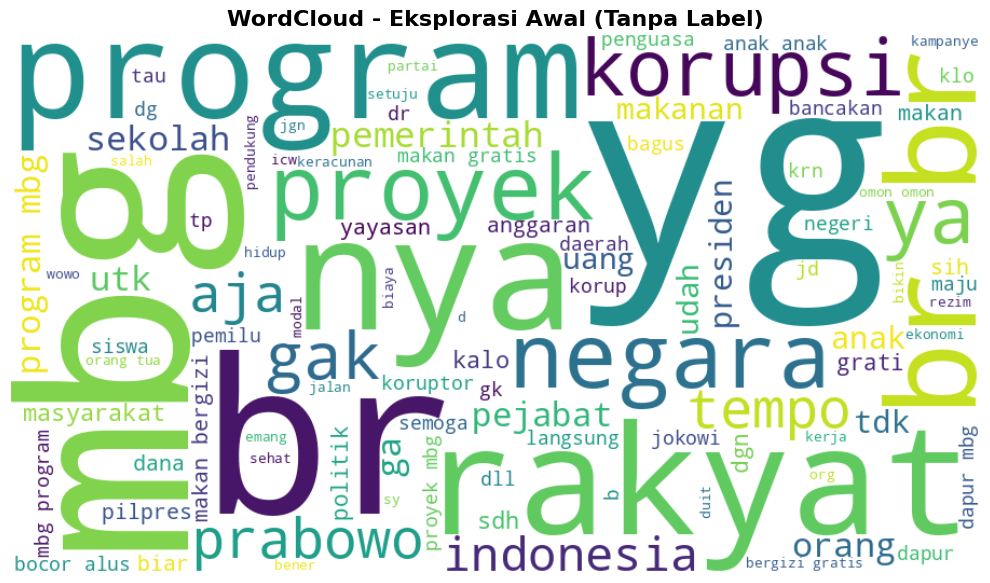

In [11]:
# Buat WordCloud
wc_all = WordCloud(
    width=900,
    height=500,
    background_color='white',
    max_words=100,
    colormap='viridis',
    stopwords=stop_words_set  # abaikan stopwords
).generate(all_text)

plt.figure(figsize=(14,7))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Eksplorasi Awal (Tanpa Label)", fontsize=16, fontweight='bold')
plt.savefig("results/wordcloud_eksplorasi_awal.png", dpi=150, bbox_inches='tight')
plt.show()

# **Definisikan Lexicon**

In [12]:
negative_words = {
    'korupsi','korup','koruptor','bubarkan','hancur','parah','sengsara','bangsat','edan','jijik','mampus','busuk','basi',
    'gagal','bohong','tipu','akal-akalan','penderitaan','rezim','penguasa','oligarki','markus','bancakan','bagi-bagi','kroni',
    'cawe','proyek','dapur','pencitraan','bencana','rugi','tolol','bodoh','bego','gila','sampah',
    'bocor','bocoran','omon','ngibul','bohongin','teko','dagelan','lawak','komedi',
    'pembohong','penipu','penjarakan','hentikan','stop','musnahkan','enyah',
    'tendang','lengser','gagal total','bobrok','amburadul','ngaco','ngawur',
    'permainan','mainan','sandal jepit','uang rakyat','apbn bocor',
}

positive_words = {
    'terima kasih','bagus','sehat','manfaat','membantu','sukses','lanjutkan','setuju','dukung','hebat','pintar','cerdas',
    'sejahtera','makmur','gratis','berkualitas','baik','peduli','bangga','harapan','yakin','percaya','patriotik','jaya',
    'berhasil','mantap','luar biasa','keren','top','kagum',
}

def lexicon_label(text):
    text_lower = text.lower()
    # Cek kata/frasa negatif (prioritas)
    for phrase in negative_words:
        if phrase in text_lower:
            return 2  # negatif
    # Cek positif
    for phrase in positive_words:
        if phrase in text_lower:
            return 1  # positif
    return None  # tidak ditemukan

# **Auto‑Labeling Sentimen dengan mdhugol/indonesia-ber**

In [13]:
classifier = pipeline(
    "sentiment-analysis",
    model="mdhugol/indonesia-bert-sentiment-classification",
    return_all_scores=True
)
label_map = {'LABEL_0': 2, 'LABEL_1': 0, 'LABEL_2': 1}

def auto_label_and_confidence(text):
    try:
        scores = classifier(text[:512])[0]
        top = max(scores, key=lambda x: x['score'])
        return label_map[top['label']], top['score']
    except:
        return 0, 0.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# **Combined Labeling**

In [14]:
def combined_label(text):
    lex = lexicon_label(text)
    if lex is not None:
        return lex, 1.0  # confidence penuh
    else:
        return auto_label_and_confidence(text)

# Jalankan labeling
results = df['clean_text'].apply(combined_label)
df['label'] = results.apply(lambda x: x[0])
df['confidence'] = results.apply(lambda x: x[1])

print("Distribusi label (setelah lexicon + auto-label):")
print(df['label'].value_counts())
print("Rata-rata confidence:", df['confidence'].mean())

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Distribusi label (setelah lexicon + auto-label):
label
2    2396
0    2392
1     847
Name: count, dtype: int64
Rata-rata confidence: 0.5755102040816327


# **WordCloud per Kelas**

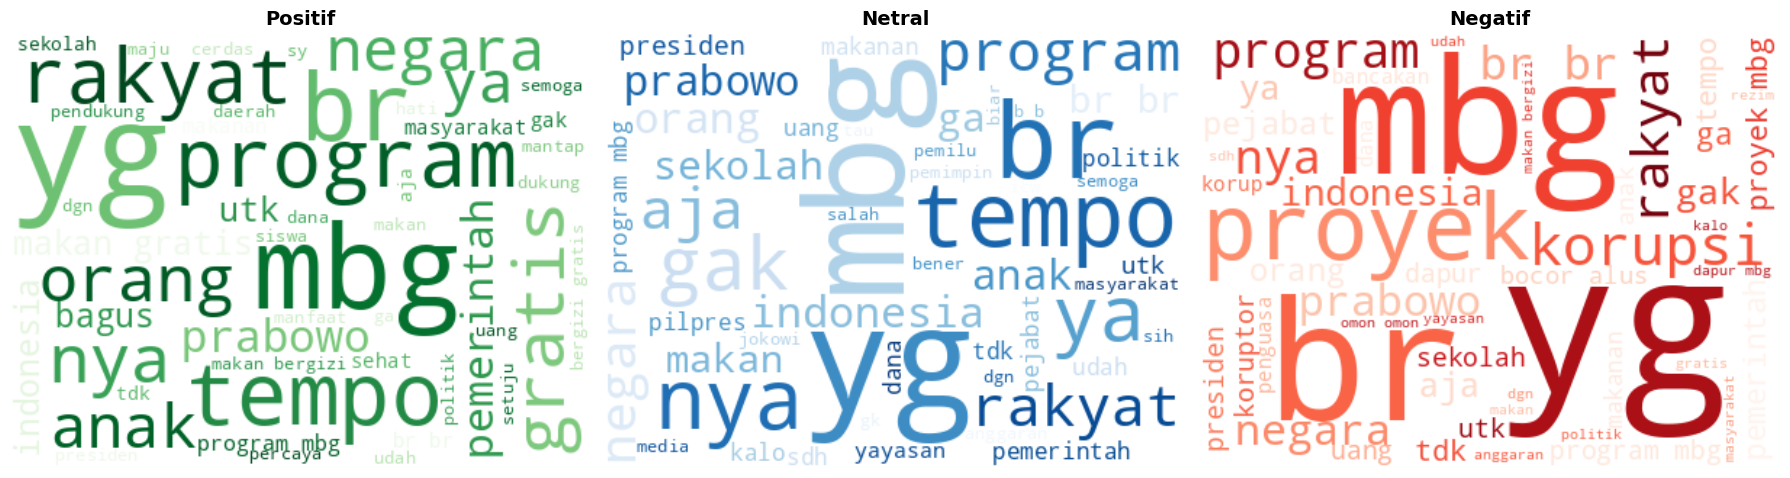

In [15]:
fig, axes = plt.subplots(1,3,figsize=(18,6))
for ax, lbl, title, cmap in zip(axes, [1,0,2], ['Positif','Netral','Negatif'], ['Greens','Blues','Reds']):
    text = " ".join(df[df['label']==lbl]['clean_text'])
    wc = WordCloud(width=400, height=300, background_color='white', colormap=cmap, max_words=50).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.set_title(title, fontsize=14, fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.savefig("results/wordcloud_per_kelas.png", dpi=150); plt.show()

# **Visualisasi Distribusi**

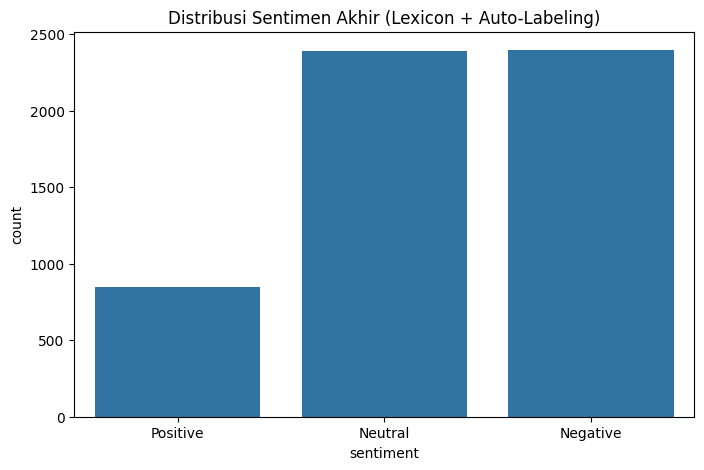

In [16]:
class_names = {0: "Neutral", 1: "Positive", 2: "Negative"}
df['sentiment'] = df['label'].map(class_names)

plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, order=['Positive','Neutral','Negative'])
plt.title("Distribusi Sentimen Akhir (Lexicon + Auto-Labeling)")
plt.savefig("results/sentiment_distribution.png")
plt.show()

# **Siapkan Data (Tokenisasi & Padding)**

In [17]:
def build_vocab(texts, max_vocab=15000):
    counter = Counter()
    for t in texts: counter.update(t.split())
    vocab = {'<PAD>':0, '<UNK>':1}
    for w, _ in counter.most_common(max_vocab):
        vocab[w] = len(vocab)
    return vocab

vocab = build_vocab(df['clean_text'], max_vocab=15000)
vocab_size = len(vocab)
max_len = 60

def encode_text(text):
    ids = [vocab.get(t, 1) for t in text.split()[:max_len]]
    return ids + [0]*(max_len - len(ids))

df['encoded'] = df['clean_text'].apply(encode_text)

X = np.array(df['encoded'].tolist())
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4508, 60) Test: (1127, 60)


# **DataLoader**

In [18]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(SentimentDataset(X_test, y_test), batch_size=batch_size)

# **Model LSTM + Attention**

In [19]:
class AttentionLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=200, hidden_dim=256, output_dim=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hidden_dim*2, 1)
        self.fc = nn.Linear(hidden_dim*2, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = self.embedding(x)
        outputs, _ = self.lstm(x)
        attn = torch.softmax(self.attention(outputs).squeeze(-1), dim=1)
        context = torch.sum(outputs * attn.unsqueeze(-1), dim=1)
        return self.fc(self.dropout(context))

model_lstm = AttentionLSTM(len(vocab)).to(device)
print(model_lstm)

AttentionLSTM(
  (embedding): Embedding(12543, 200, padding_idx=0)
  (lstm): LSTM(200, 256, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (fc): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


# **Model GRU + Attention**

In [20]:
class AttentionGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim=200, hidden_dim=256, output_dim=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hidden_dim*2, 1)
        self.fc = nn.Linear(hidden_dim*2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        outputs, _ = self.gru(x)
        attn = torch.softmax(self.attention(outputs).squeeze(-1), dim=1)
        context = torch.sum(outputs * attn.unsqueeze(-1), dim=1)
        return self.fc(self.dropout(context))

model_gru = AttentionGRU(vocab_size).to(device)
print(model_gru)

AttentionGRU(
  (embedding): Embedding(12543, 200, padding_idx=0)
  (gru): GRU(200, 256, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (fc): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


# **Training Function untuk LSTM dan GRU**

In [21]:
def train_rnn(model, train_loader, test_loader, y_train, epochs=15, lr=0.0005, log_dir="logs/tensorboard/rnn", model_path="models/rnn_model.pt"):
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    writer = SummaryWriter(log_dir=log_dir)
    best_acc = 0.0; history = {'train_loss':[],'val_acc':[],'val_f1':[]}
    start = time.time()
    for epoch in range(epochs):
        model.train(); total_loss = 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(); loss = criterion(model(inputs), labels); loss.backward(); optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        writer.add_scalar("Loss/train", avg_loss, epoch)
        model.eval(); preds, truths = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device); outputs = model(inputs)
                preds.extend(outputs.argmax(1).cpu().numpy()); truths.extend(labels.numpy())
        acc = accuracy_score(truths, preds); f1 = f1_score(truths, preds, average='weighted')
        writer.add_scalar("Accuracy/val", acc, epoch); writer.add_scalar("F1/val", f1, epoch)
        history['train_loss'].append(avg_loss); history['val_acc'].append(acc); history['val_f1'].append(f1)
        print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Acc {acc:.4f} | F1 {f1:.4f}")
        if acc > best_acc:
            best_acc = acc; torch.save(model.state_dict(), model_path); print("  -> saved best")
    writer.close()
    return history, time.time() - start

# **Training LSTM dan GRU**

In [22]:
history_lstm, t_lstm = train_rnn(model_lstm, train_loader, test_loader, y_train, epochs=15, log_dir="logs/tensorboard/lstm", model_path="models/lstm_model.pt")
history_gru, t_gru   = train_rnn(model_gru,   train_loader, test_loader, y_train, epochs=15, log_dir="logs/tensorboard/gru",  model_path="models/gru_model.pt")

Epoch 1: 100%|██████████| 71/71 [00:02<00:00, 25.59it/s]


Epoch 1: Loss 0.9562 | Acc 0.6930 | F1 0.7043
  -> saved best


Epoch 2: 100%|██████████| 71/71 [00:01<00:00, 69.78it/s]


Epoch 2: Loss 0.6213 | Acc 0.7853 | F1 0.7913
  -> saved best


Epoch 3: 100%|██████████| 71/71 [00:00<00:00, 73.18it/s]


...

Epoch 13: Loss 0.0016 | Acc 0.8589 | F1 0.8586


Epoch 14: 100%|██████████| 71/71 [00:00<00:00, 108.56it/s]


Epoch 14: Loss 0.0010 | Acc 0.8580 | F1 0.8577


Epoch 15: 100%|██████████| 71/71 [00:00<00:00, 108.34it/s]


Epoch 15: Loss 0.0008 | Acc 0.8580 | F1 0.8578


# **Evaluasi LSTM dan GRU**

=== LSTM ===
Acc: 0.8722 | Prec: 0.8746 | Rec: 0.8722 | F1: 0.8728
              precision    recall  f1-score   support

     Neutral       0.86      0.90      0.88       479
    Positive       0.74      0.76      0.75       169
    Negative       0.94      0.88      0.91       479

    accuracy                           0.87      1127
   macro avg       0.85      0.85      0.85      1127
weighted avg       0.87      0.87      0.87      1127



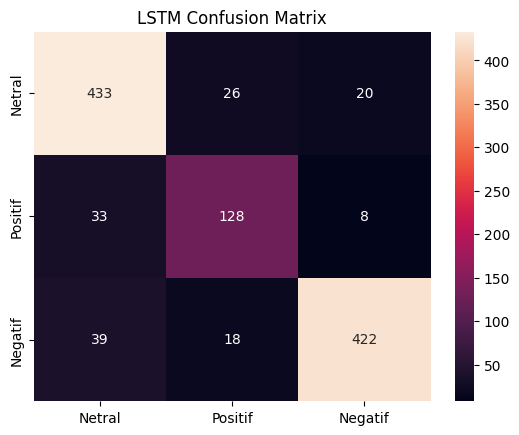

=== GRU ===
Acc: 0.8598 | Prec: 0.8595 | Rec: 0.8598 | F1: 0.8592
              precision    recall  f1-score   support

     Neutral       0.89      0.85      0.87       479
    Positive       0.78      0.74      0.76       169
    Negative       0.86      0.91      0.89       479

    accuracy                           0.86      1127
   macro avg       0.84      0.83      0.84      1127
weighted avg       0.86      0.86      0.86      1127



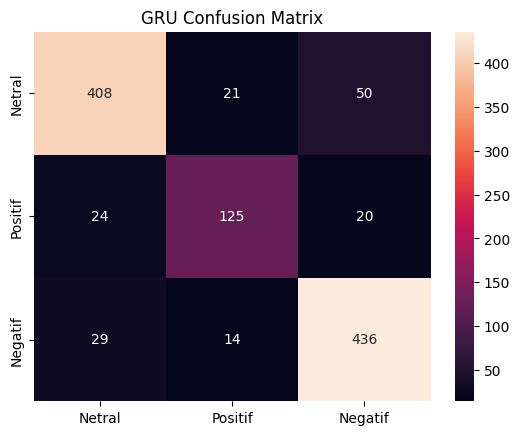

In [23]:
def evaluate_rnn(model, test_loader, name):
    model.load_state_dict(torch.load(f"models/{name}_model.pt")); model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for inputs, lbls in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds.extend(outputs.argmax(1).cpu().numpy()); labels.extend(lbls.numpy())
    acc = accuracy_score(labels, preds); prec = precision_score(labels, preds, average='weighted')
    rec = recall_score(labels, preds, average='weighted'); f1 = f1_score(labels, preds, average='weighted')
    print(f"=== {name.upper()} ===")
    print(f"Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    print(classification_report(labels, preds, target_names=['Neutral','Positive','Negative']))
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Netral','Positif','Negatif'], yticklabels=['Netral','Positif','Negatif'])
    plt.title(f"{name.upper()} Confusion Matrix"); plt.savefig(f"results/cm_{name}.png"); plt.show()
    return acc, prec, rec, f1

acc_lstm, prec_lstm, rec_lstm, f1_lstm = evaluate_rnn(model_lstm, test_loader, "lstm")
acc_gru,  prec_gru,  rec_gru,  f1_gru  = evaluate_rnn(model_gru,  test_loader, "gru")

# **Fine‑tuning IndoBERT untuk Klasifikasi Sentimen**

In [24]:
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased")

# Gunakan versi teks yang hanya di-lowercase tanpa stopword removal untuk BERT
def tokenize_fn(examples):
    return tokenizer(examples['bert_text'], padding='max_length', truncation=True, max_length=128)

train_hf = HfDataset.from_pandas(df_train[['bert_text','label']])
test_hf = HfDataset.from_pandas(df_test[['bert_text','label']])
train_hf = train_hf.map(tokenize_fn, batched=True)
test_hf = test_hf.map(tokenize_fn, batched=True)
train_hf = train_hf.rename_column('label', 'labels')
test_hf = test_hf.rename_column('label', 'labels')
train_hf.set_format('torch', columns=['input_ids','attention_mask','labels'])
test_hf.set_format('torch', columns=['input_ids','attention_mask','labels'])

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/4508 [00:00<?, ? examples/s]

Map:   0%|          | 0/1127 [00:00<?, ? examples/s]

# **Trainer IndoBERT dengan Early Stopping**

In [25]:
model_bert = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobert-base-uncased", num_labels=3
).to(device)

training_args = TrainingArguments(
    output_dir="./models/indobert_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs/tensorboard/indobert",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

start_bert = time.time()
trainer.train()
train_time_bert = time.time() - start_bert

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecat

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.838890,0.754180,0.684117,0.658252


Error during conversion: AttributeError("'str' object has no attribute 'decode'")


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

# **Evaluasi IndoBERT & Simpan Model**

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

IndoBERT -> Acc: 0.9077, Prec: 0.9087, Rec: 0.9077, F1: 0.9079
              precision    recall  f1-score   support

     Neutral       0.93      0.90      0.91       479
    Positive       0.82      0.86      0.84       169
    Negative       0.92      0.94      0.93       479

    accuracy                           0.91      1127
   macro avg       0.89      0.90      0.89      1127
weighted avg       0.91      0.91      0.91      1127



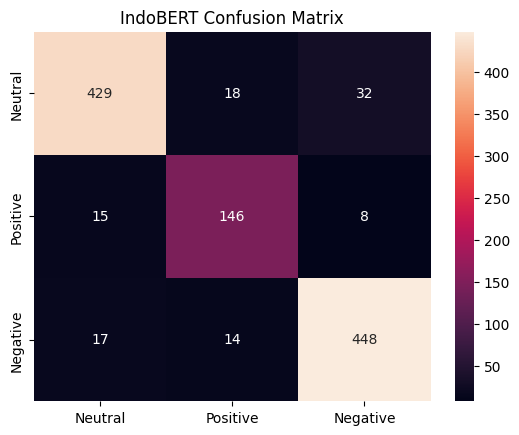

In [26]:
trainer.save_model("models/indobert_model")

preds = trainer.predict(test_hf)
preds_bert = np.argmax(preds.predictions, axis=-1)
labels_bert = preds.label_ids

acc_bert = accuracy_score(labels_bert, preds_bert)
prec_bert = precision_score(labels_bert, preds_bert, average='weighted')
rec_bert = recall_score(labels_bert, preds_bert, average='weighted')
f1_bert = f1_score(labels_bert, preds_bert, average='weighted')

print(f"IndoBERT -> Acc: {acc_bert:.4f}, Prec: {prec_bert:.4f}, Rec: {rec_bert:.4f}, F1: {f1_bert:.4f}")
print(classification_report(labels_bert, preds_bert, target_names=['Neutral','Positive','Negative']))

cm_bert = confusion_matrix(labels_bert, preds_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', xticklabels=['Neutral','Positive','Negative'], yticklabels=['Neutral','Positive','Negative'])
plt.title("IndoBERT Confusion Matrix")
plt.savefig("results/cm_bert.png")
plt.show()

# **Tabel Perbandingan & Simpan Hasil**

In [28]:
comparison_df = pd.DataFrame({
    "Model": ["LSTM + Attention", "GRU + Attention", "IndoBERT (fine-tuned)"],
    "Accuracy": [acc_lstm, acc_gru, acc_bert],
    "Precision": [prec_lstm, prec_gru, prec_bert],
    "Recall": [rec_lstm, rec_gru, rec_bert],
    "F1-Score": [f1_lstm, f1_gru, f1_bert],
    "Training Time (s)": [t_lstm, t_gru, train_time_bert]
})
comparison_df.to_csv("results/comparison.csv", index=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,LSTM + Attention,0.872227,0.874596,0.872227,0.872765,19.098185
1,GRU + Attention,0.859805,0.859536,0.859805,0.859167,11.168312
2,IndoBERT (fine-tuned),0.907720,0.908701,0.907720,0.907949,936.071440


# **Visualisasi Perbandingan**

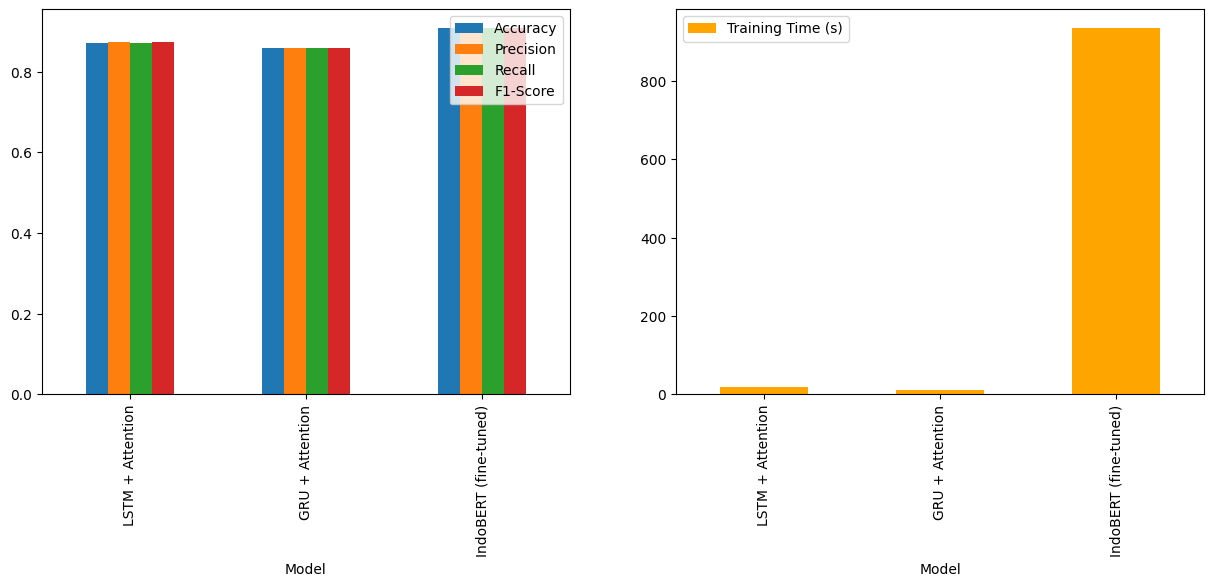

In [29]:
fig, axes = plt.subplots(1,2,figsize=(15,5))
comparison_df.plot(x="Model", y=["Accuracy","Precision","Recall","F1-Score"], kind="bar", ax=axes[0])
comparison_df.plot(x="Model", y="Training Time (s)", kind="bar", color="orange", ax=axes[1])
plt.savefig("results/comparison_plot.png")
plt.show()

# **Inferensi Interaktif**

In [31]:
import ipywidgets as widgets; from IPython.display import display, clear_output

def predict_rnn(text, model, vocab):
    cleaned = clean_text(text); ids = [vocab.get(t,1) for t in cleaned.split()[:60]]
    ids += [0]*(60-len(ids)); inp = torch.tensor([ids], dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        out = model(inp); prob = torch.softmax(out, dim=1).cpu().numpy()[0]
        return ['Netral','Positif','Negatif'][out.argmax(1).item()], prob

def predict_bert_inf(text):
    tok = tokenizer(text, padding='max_length', truncation=True, max_length=128, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model_bert(**tok); prob = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        return ['Netral','Positif','Negatif'][out.logits.argmax(1).item()], prob

txt = widgets.Textarea(placeholder='Ketik komentar...', layout=widgets.Layout(width='80%',height='100px'))
btn = widgets.Button(description='Prediksi', button_style='primary'); out = widgets.Output()
def on_click(b):
    if txt.value.strip()=='': return
    t = txt.value.strip(); s_lstm, p_lstm = predict_rnn(t, model_lstm, vocab); s_gru, p_gru = predict_rnn(t, model_gru, vocab); s_bert, p_bert = predict_bert_inf(t)
    with out: clear_output(); print(f"📝 Input: \"{t[:200]}\""); print(f"🔵 LSTM   : {s_lstm} ({p_lstm})"); print(f"🟢 GRU    : {s_gru} ({p_gru})"); print(f"🟠 IndoBERT: {s_bert} ({p_bert})")
btn.on_click(on_click); display(widgets.VBox([txt, btn, out]))

# **Requirements.txt & Download**

In [32]:
from importlib.metadata import version

libs = ["transformers","datasets","torch","scikit-learn","matplotlib","seaborn","tqdm","pandas","numpy","tensorboard","nltk","wordcloud","ipywidgets"]
with open("requirements.txt","w") as f:
    for lib in libs:
        try: f.write(f"{lib}=={version(lib)}\n")
        except: pass
!zip -r /content/Kode_sentimenAnalisis_MBG_V3.zip /content/models /content/results /content/logs /content/requirements.txt

  adding: content/models/ (stored 0%)
  adding: content/models/gru_model.pt (deflated 8%)
  adding: content/models/lstm_model.pt (deflated 8%)
  adding: content/models/indobert_model/ (stored 0%)
  adding: content/models/indobert_model/training_args.bin (deflated 53%)
  adding: content/models/indobert_model/checkpoint-705/ (stored 0%)
  adding: content/models/indobert_model/checkpoint-705/rng_state.pth (deflated 26%)
  adding: content/models/indobert_model/checkpoint-705/training_args.bin (deflated 53%)
  adding: content/models/indobert_model/checkpoint-705/trainer_state.json (deflated 77%)
  adding: content/models/indobert_model/checkpoint-705/scheduler.pt (deflated 61%)
  adding: content/models/indobert_model/checkpoint-705/config.json (deflated 55%)
  adding: content/models/indobert_model/checkpoint-705/optimizer.pt (deflated 23%)
  adding: content/models/indobert_model/checkpoint-705/model.safetensors (deflated 7%)
  adding: content/models/indobert_model/config.json (deflated 55%)


# **Mount Drive dan Simpan**

In [33]:
from google.colab import drive
drive.mount('/content/drive')

!cp Kode_sentimenAnalisis_MBG_V3.zip /content/drive/MyDrive/

Mounted at /content/drive
cp: error writing '/content/drive/MyDrive/Kode_sentimenAnalisis_MBG_V3.zip': Transport endpoint is not connected
cp: failed to close '/content/drive/MyDrive/Kode_sentimenAnalisis_MBG_V3.zip': Transport endpoint is not connected
